# Exploratory Data Analysis

This notebook sets the foundation for the classification task by answering 3 questions:

1. Demographic and cognitive profile for each group. Who are these children?
2. EEG Spectral and topographic analysis. Do the group differ neurally?
3. A cross modal correlation analysis. Do both modalities carry complementary information? 

The idea is to understand if EEG and psuchometrics are highly redundant, if so a simple psychometric classifiers will be enough. If they are complementary, our idea of a multimodal fusion is justified, motivating the attention gating architecture.

- Figures saved to `notebooks/figures/`

In [ ]:
#Libraries
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Ellipse
import seaborn as sns
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import mne
from mne.time_frequency import psd_array_welch
from pathlib import Path
from tqdm import tqdm
warnings.filterwarnings('ignore')
mne.set_log_level('WARNING')


#General Format
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.15)
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,'axes.spines.right': False, 'figure.facecolor': 'white'})


PALETTE  = {'RD': '#4C72B0', 'MD': '#DD8452'}
BANDS    = {'delta': (1,4), 'theta': (4,8), 'alpha': (8,13), 'beta': (13,30)}
REGIONS  = ['frontal','frontocentral','central','centroparietal','temporal','parietal','occipital']

In [10]:
#Paths
ROOT = Path('C:/Users/diego/Desktop/multimodal-neucog')
DATA_RAW = ROOT/'data'/'raw'/'ds006260'
PROC = ROOT/'data'/'processed'
FIG_DIR  = ROOT/'notebooks'/'figures'
FIG_DIR.mkdir(exist_ok=True)

In [13]:
# Load Data
psycho = pd.read_csv(PROC/'psycho_features_pre.csv')
eeg = pd.read_csv(PROC/'eeg_features_pre.csv')

eeg_cols = [c for c in eeg.columns if c.startswith(('baseline_','task_'))]
print(f'Psychometric: {psycho.shape}  RD={(psycho.label=="RD").sum()} MD={(psycho.label=="MD").sum()}')
print(f'EEG: {eeg.shape}  RD={(eeg.label=="RD").sum()} MD={(eeg.label=="MD").sum()}')
print(f'EEG range: [{eeg[eeg_cols].min().min():.1f}, {eeg[eeg_cols].max().max():.1f}] log10 V2/Hz')

Psychometric: (76, 13)  RD=35 MD=41
EEG: (75, 58)  RD=35 MD=40
EEG range: [-12.9, -2.6] log10 V2/Hz



## 1. Who Are These Children?

### 1.1 Demographic Overview

Distribution of age, gender, and intervention subgroup for RD and MD groups.

Before any analysis we verify the groups are comparable on general characteristics. A difference in age or genede could corrupt the neural and cognitive differences we observe. We also take a look that control and experimental subgrpups are balanced within each group. We are using only PRE-intervention data, this subgroup structure should not introduce any bias.

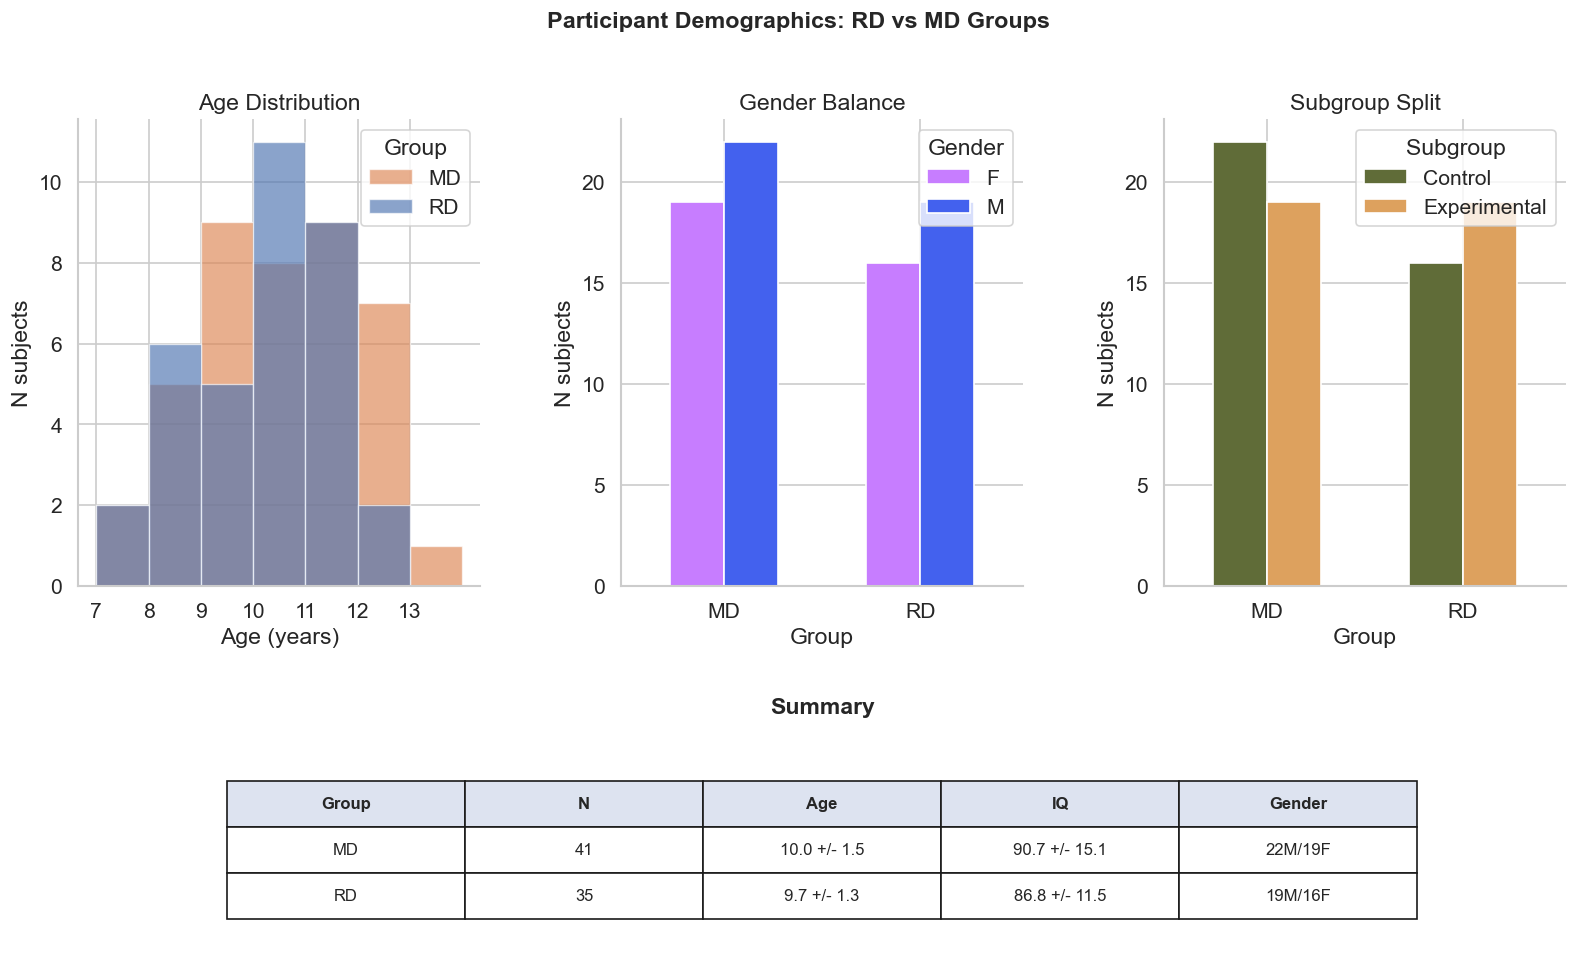

In [17]:
fig = plt.figure(figsize=(16, 9))

gs = gridspec.GridSpec(
    2, 3, 
    figure=fig, 
    height_ratios=[2.2, 1],
    hspace=0.45,
    wspace=0.35) 

# Age
ax0 = fig.add_subplot(gs[0, 0])
for label, df in psycho.groupby('label'):
    
    ax0.hist(df['age'], bins=range(7, 15), alpha=0.65, label=label,
             color=PALETTE[label], edgecolor='white', linewidth=0.8)

ax0.set_xlabel('Age (years)')
ax0.set_ylabel('N subjects')
ax0.set_title('Age Distribution')
ax0.legend(title='Group')
ax0.set_xticks(range(7, 14))


# Gender
ax1 = fig.add_subplot(gs[0, 1])
gc = psycho.groupby(['label', 'gender']).size().unstack(fill_value=0)
gc.plot(kind='bar', ax=ax1, color=['#c77dff', '#4361ee'], edgecolor='white', width=0.55)

ax1.set_xlabel('Group')
ax1.set_ylabel('N subjects')
ax1.set_title('Gender Balance')
ax1.set_xticklabels(['MD', 'RD'], rotation=0)
ax1.legend(title='Gender')


# Control vs Experimental
ax2 = fig.add_subplot(gs[0, 2])

psycho['subgroup'] = psycho['subject_id'].apply(lambda s: 'Control' if s.split('-')[1][1].lower() == 'c' else 'Experimental')
sg = psycho.groupby(['label', 'subgroup']).size().unstack(fill_value=0)
sg.plot(kind='bar', ax=ax2, color=['#606c38', '#dda15e'], edgecolor='white', width=0.55)

ax2.set_xlabel('Group')
ax2.set_ylabel('N subjects')
ax2.set_title('Subgroup Split')
ax2.set_xticklabels(['MD', 'RD'], rotation=0)
ax2.legend(title='Subgroup')


# Summary table
ax3 = fig.add_subplot(gs[1, :])
ax3.axis('off')

rows = []

for lbl, df in psycho.groupby('label'):
    rows.append([
        lbl, 
        len(df),
        f"{df['age'].mean():.1f} +/- {df['age'].std():.1f}",
        f"{df['IQ'].mean():.1f} +/- {df['IQ'].std():.1f}",
        f"{(df['gender'] == 'M').sum()}M/{(df['gender'] == 'F').sum()}F"])

t = ax3.table(
    cellText=rows,
    colLabels=['Group', 'N', 'Age', 'IQ', 'Gender'],
    cellLoc='center',
    loc='center',
    bbox=[0.1, 0.15, 0.8, 0.65])

t.auto_set_font_size(False)
t.set_fontsize(10)

for (r, c), cell in t.get_celld().items():
    cell.set_facecolor('#dde3f0' if r == 0 else 'white')
    if r == 0:
        cell.set_text_props(fontweight='bold')

ax3.set_title('Summary', fontweight='bold', pad=15)


# Overall Title
fig.suptitle('Participant Demographics: RD vs MD Groups',fontsize=14,fontweight='bold',y=0.98)
plt.savefig(FIG_DIR / '01_demographics.png', bbox_inches='tight', dpi=150)
plt.show()

**Interpretation:** 

Both groups are demographically comparable. Age distributions overlap bustantially, with means of 10.0 $\pm$ 1.5 years (MD) and 9.7 $\pm$ 1.3 years (RD). Gender balance is similar across groups (~54 % male in both). The control/experimental subgrpup split is reasonably balanced within each group. IQ scores are close between groups (MD: 90.7 $\pm$ 15.1 vs RD: 86.8 $\pm$ 11.5), indicating that any neural or cognitive differences found in future analysis are not driven by differences in general intellectual ability. 

Therefore, these groups are well-matched on demographic and general cognitive variables.


## 2. Psychometric Profiles

### 2.1 Shared Cognitive Features: IQ and Selective Attention

Violin plots comparing IQ and selective attention between RD and MD, with Mann-Whitney U tests and Cohen's d effect sizes.

IQ and selective attention are domain general abilities, they are not specific to reading or math. If there are similar between groups (not significant), it confirms the groups are matched on general cognitive ability. Let's remember we are comparing children with specific difficultires in different learning domains, we are not comparing "smarter" vs "less smarter" children.

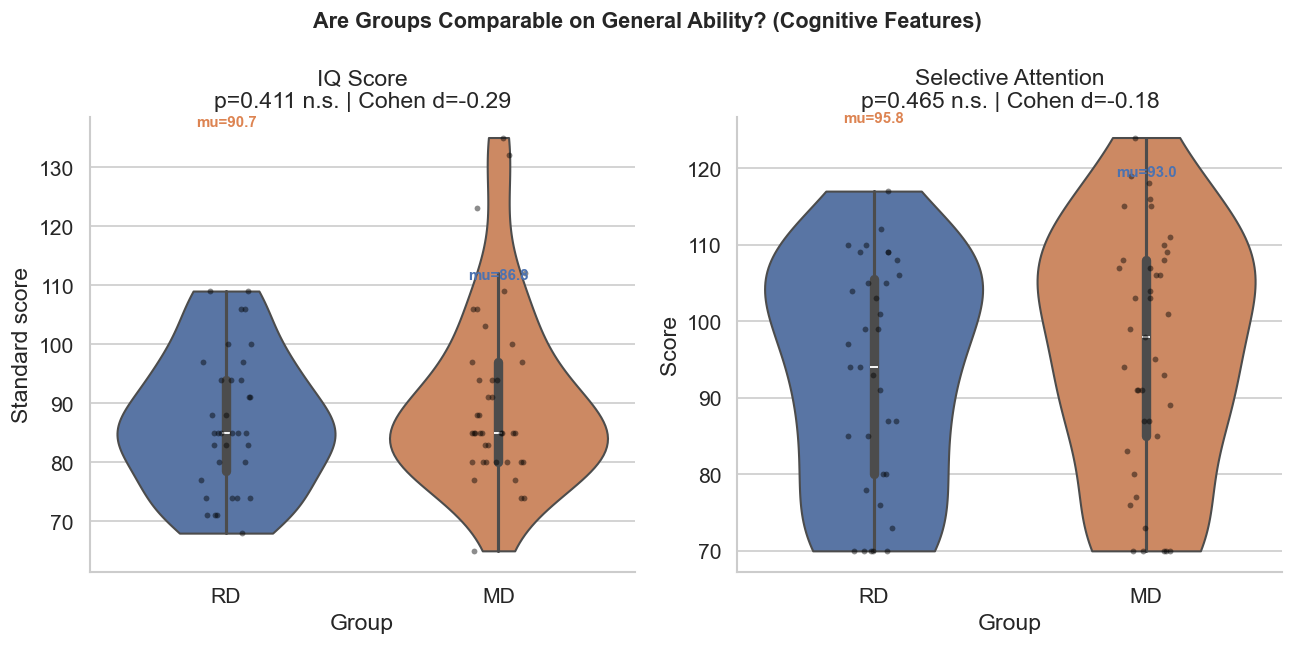

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))

#Title
fig.suptitle('Are Groups Comparable on General Ability? (Cognitive Features)',
             fontsize=13, fontweight='bold')

for ax, (col, title, unit) in zip(axes, [('IQ', 'IQ Score', 'Standard score'),('selective_attention', 'Selective Attention', 'Score'),]):
    
    # Violin + Strip Plot for each feature
    sns.violinplot(data=psycho, x='label', y=col, palette=PALETTE,inner='box', ax=ax, order=['RD','MD'], cut=0)
    sns.stripplot(data=psycho, x='label', y=col, color='black',size=3.5, alpha=0.45, ax=ax, order=['RD','MD'], jitter=True)

    # We compute Mann-Whitney U test and Cohen's d for effect size 
    # (This will tell us if there are significant differences between groups on these general cognitive features)
    rd_v = psycho[psycho.label=='RD'][col].dropna()
    md_v = psycho[psycho.label=='MD'][col].dropna()
    _, p = stats.mannwhitneyu(rd_v, md_v, alternative='two-sided')
    d = (rd_v.mean()-md_v.mean()) / np.sqrt((rd_v.std()**2+md_v.std()**2)/2)
    sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'n.s.'
    
    ax.set_title(f'{title}\np={p:.3f} {sig} | Cohen d={d:.2f}')
    ax.set_xlabel('Group'); ax.set_ylabel(unit)
    for i, (lbl, grp) in enumerate(psycho.groupby('label')):
        ax.text(i, grp[col].max()+2, f'mu={grp[col].mean():.1f}',
                ha='center', fontsize=9, fontweight='bold', color=PALETTE[lbl])

plt.tight_layout()
plt.savefig(FIG_DIR/'02_shared_cognitive.png', bbox_inches='tight', dpi=150)
plt.show()

**Interpretation:** 

Neither IQ (p = 0.411, d = −0.29) nor selective attention (p = 0.465, d = −0.18) differ significantly between groups. Both effect sizes are small, confirming that the two groups are equivalent on a general domain cognitive ability. This is the desired result, these children have specifit learning difficulties, not global cognitive impairment.

The key implication of all of this: If standard cognitive assesment (IQ, attention) cannot discriminate RD from MD, then psychometric ascores and neural signals (EEG) are essential. This motivates our multimodal fusion approach.

### 2.2 Domain-Specific Cognitive Profiles

We create boxplots of the cognitive scores specific to each group:
 - For RD the reading metrics (orthographic errors, phonological errors, reading speed, comprehension)
 - For MD the math metrics (WRAT-4 score, hit rate, reaction time)

These variables define each learning difficulty. Understanding variability within each group will tells us how heteregeneous the profiles are. A wide distribution suggest diverse levels, making classification harder.

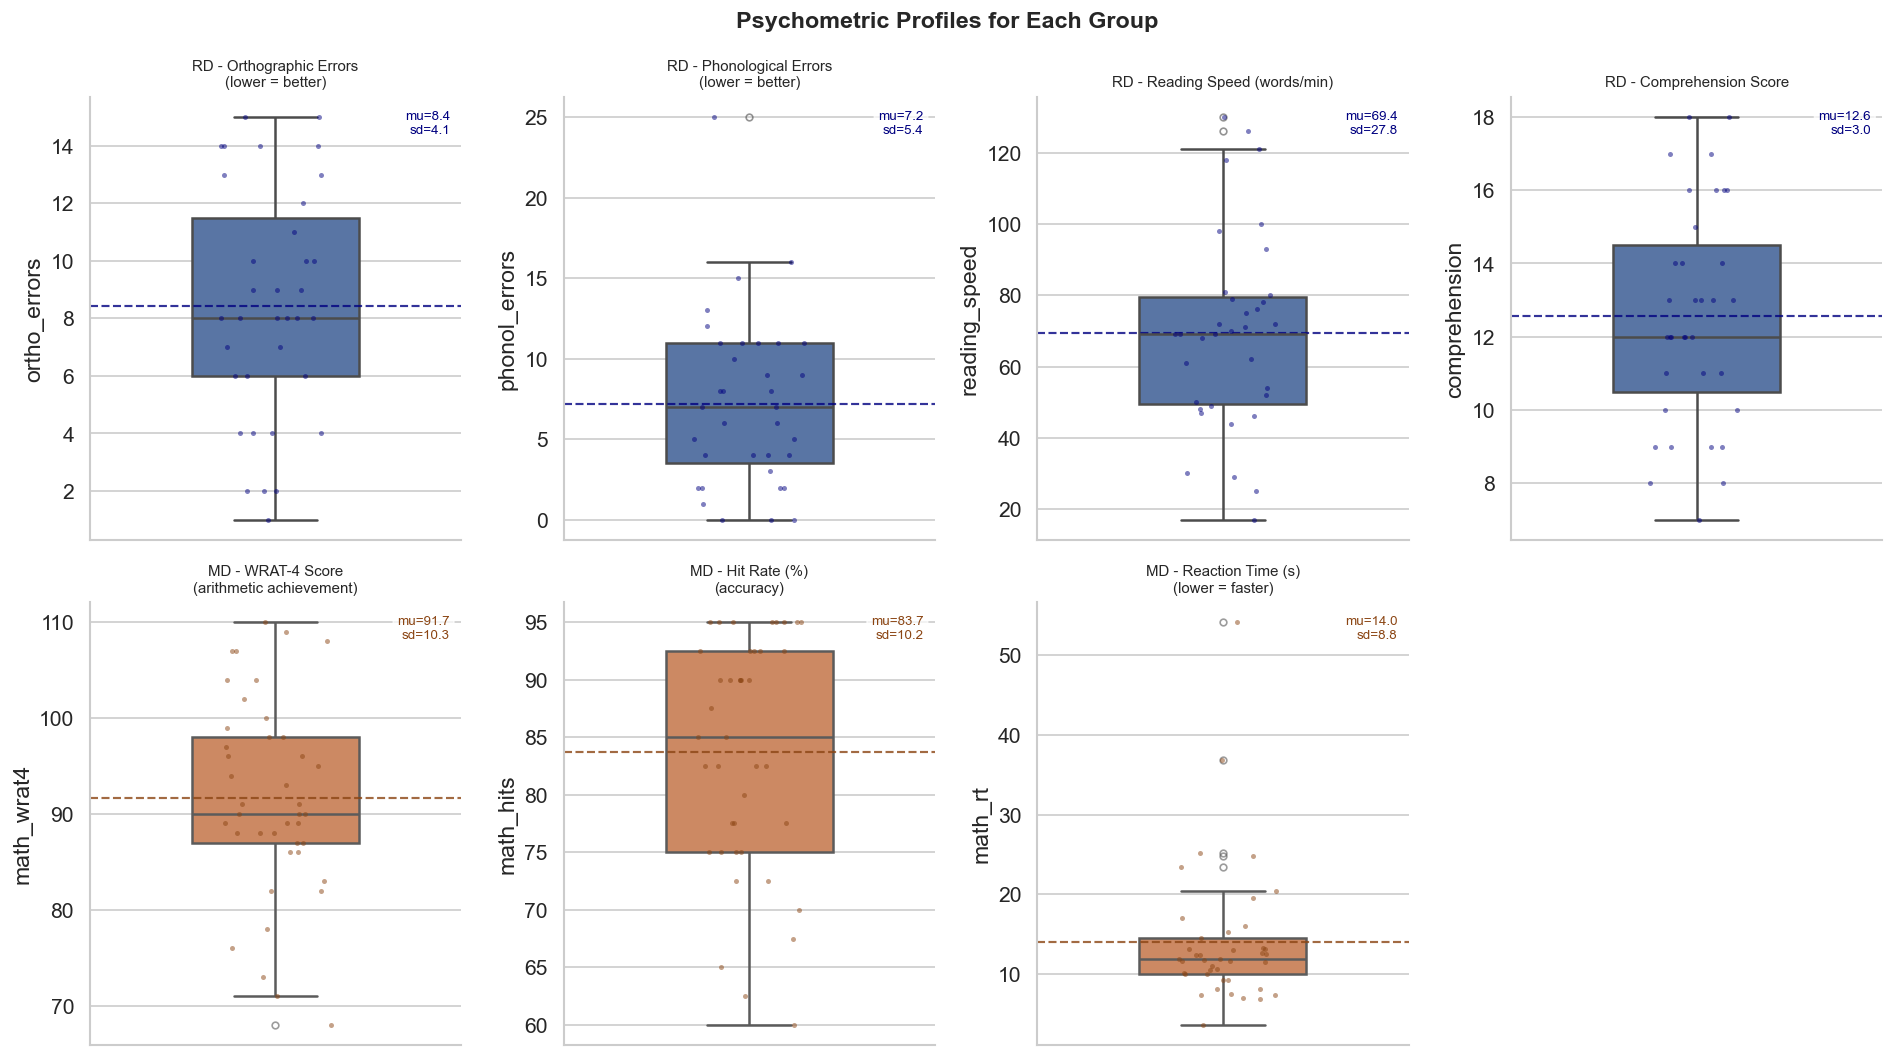

In [23]:
fig, axes = plt.subplots(2, 4, figsize=(16, 9))
fig.suptitle('Psychometric Profiles for Each Group', fontsize=14, fontweight='bold')

# Reading Disorder Box plots
rd = psycho[psycho.label=='RD']
rd_specs = [
    ('ortho_errors',  'Orthographic Errors\n(lower = better)', '#4C72B0'),
    ('phonol_errors', 'Phonological Errors\n(lower = better)', '#4C72B0'),
    ('reading_speed', 'Reading Speed (words/min)', '#4C72B0'),
    ('comprehension', 'Comprehension Score', '#4C72B0'),
]
for ax, (col, title, color) in zip(axes[0], rd_specs):
    sns.boxplot(y=rd[col], ax=ax, color=color, width=0.45, linewidth=1.5,
                flierprops=dict(marker='o', markersize=4, alpha=0.6))
    sns.stripplot(y=rd[col], ax=ax, color='navy', size=3, alpha=0.5, jitter=0.15)
    m = rd[col].mean(); sd = rd[col].std()
    ax.axhline(m, color='navy', linestyle='--', linewidth=1.3, alpha=0.8)
    ax.set_title(f'RD - {title}', fontsize=9)
    ax.text(0.97, 0.97, f'mu={m:.1f}\nsd={sd:.1f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=8, color='navy',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

# Math Disorder Box plots
md_df = psycho[psycho.label=='MD']
md_specs = [
    ('math_wrat4', 'WRAT-4 Score\n(arithmetic achievement)', '#DD8452'),
    ('math_hits',  'Hit Rate (%)\n(accuracy)', '#DD8452'),
    ('math_rt',    'Reaction Time (s)\n(lower = faster)', '#DD8452'),
]
for ax, (col, title, color) in zip(axes[1, :3], md_specs):
    sns.boxplot(y=md_df[col], ax=ax, color=color, width=0.45, linewidth=1.5,
                flierprops=dict(marker='o', markersize=4, alpha=0.6))
    sns.stripplot(y=md_df[col], ax=ax, color='saddlebrown', size=3, alpha=0.5, jitter=0.15)
    m = md_df[col].mean(); sd = md_df[col].std()
    ax.axhline(m, color='saddlebrown', linestyle='--', linewidth=1.3, alpha=0.8)
    ax.set_title(f'MD - {title}', fontsize=9)
    ax.text(0.97, 0.97, f'mu={m:.1f}\nsd={sd:.1f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=8, color='saddlebrown',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

axes[1, 3].axis('off')
plt.tight_layout()
plt.savefig(FIG_DIR/'03_domain_psychometrics.png', bbox_inches='tight', dpi=150)
plt.show()

**Interpretation:** 

Both groups show clear, coherent difficultu profiles within their respective domains.

RD children exhibit deficits across all reading components: orthographic errors ($\mu$=8.4 $\pm$ 4.1), phonological errors ($\mu$=7.2 $\pm$ 5.4), reduced reading speed ($\mu$=69.4 $\pm$ 27.8 words/min), and a moderate affected comprehension ($\mu$=12.6 $\pm$ 3.0). 


On the other hand, MD children present consistent arithmetic difficulties: borderline WRAT-4 achievement scores ($\mu$=91.7 $\pm$ 10.3), moderate accuracy on task ($\mu$=83.7%), and high reaction times ($\mu$=14.0 $\pm$ 8.8s). The Reaction time distribution is strongly right skewed with one extreme outlier (~54s), reflecting a subgroup with severe processing difficulties. 

The key value for classification is that both groups show bustatntial group variability. This heterogeneity means psychometric features alone may struggle to draw a clean boundary between groups. It highlights the value of adding EEG. This may capture the underlying processing differences that behavioural scores are not clear.


## 3. EEG Topographic Analysis

### 3.1 Computing Per-Channel Band Power

For each subject, we load the raw baseline (EEG file) and compute the PSD per individual channel (32 channels). This gives us 32 spatioal values per band per subject.

The importance of this is to brige neuroscience visualizatoin and machine learning methodology: Regional averaging (used in our future ML pipeline) is efficient for classification but loses spatial detail, this topograhic maps highlights the detail to see where in the scalp the differences originate.

In [25]:
# Build MNE Info with standard 10-20 montage
CH_NAMES = ['FP1','FP2','F7','F3','Fz','F4','F8','FT10','FT9','T7',
            'FC5','C3','FC1','FC2','FC6','C4','Cz','CP1','CP5','TP9',
            'CP2','CP6','TP10','T8','P7','P3','Pz','P4','P8','O1','Oz','O2']

info    = mne.create_info(ch_names=CH_NAMES, sfreq=256, ch_types='eeg')
montage = mne.channels.make_standard_montage('standard_1020')
info.set_montage(montage, match_case=False, on_missing='ignore')

sub_rd = eeg[eeg.label=='RD']['subject_id'].tolist()
sub_md = eeg[eeg.label=='MD']['subject_id'].tolist()

def compute_perchannel_bp(subject_list, run='run-1', desc='Group'):
    '''Compute per-channel log10 band power for a list of subjects.
    Returns dict: band -> (n_subjects, 32) array.
    '''
    all_powers = {b: [] for b in BANDS}
    for sub in tqdm(subject_list, desc=desc):
        fpath = (DATA_RAW / sub / 'ses-1' / 'eeg' /
                 f'{sub}_ses-1_task-SmartickDataset_{run}_eeg.set')
        if not fpath.exists():
            continue
        try:
            raw  = mne.io.read_raw_eeglab(str(fpath), preload=True, verbose=False)
            data = raw.get_data()
            sfreq = raw.info['sfreq']
            psds, freqs = psd_array_welch(
                data, sfreq=sfreq, fmin=1., fmax=30.,
                n_fft=int(sfreq*2), verbose=False)
            for band, (fmin, fmax) in BANDS.items():
                mask = (freqs >= fmin) & (freqs < fmax)
                bp   = psds[:, mask].mean(axis=1)
                all_powers[band].append(np.log10(np.maximum(bp, 1e-30)))
        except Exception as e:
            print(f'  Skip [{sub}]: {e}')
    return {b: np.array(v) for b, v in all_powers.items() if v}

print('Loading baseline EEG for topomaps: ')
perch_rd = compute_perchannel_bp(sub_rd, run='run-1', desc='RD baseline')
perch_md = compute_perchannel_bp(sub_md, run='run-1', desc='MD baseline')

mean_rd = {b: perch_rd[b].mean(axis=0) for b in BANDS}
mean_md = {b: perch_md[b].mean(axis=0) for b in BANDS}

print(f'Done. RD: {perch_rd["theta"].shape[0]} subj | MD: {perch_md["theta"].shape[0]} subj')

Loading baseline EEG for topomaps: 


MD baseline: 100%|██████████| 40/40 [00:04<00:00,  9.53it/s]

Done. RD: 35 subj | MD: 40 subj


### 3.2 Group-Mean Scalp Topographic Maps

We generate topomaps showing mean log10 bandpower distribution across the scalp for each frequency band: RD group, MD Group, and their difference (MD minus RD). The difference maps (MD minus RD) directly indicate which features should be most discriminative for classification.

Topomaps are the standar EEG visulization. They will reveal where in the brain power diff concentrate. Our expected patterns based on literature:
- **Theta (4-8 Hz):** Elevated frontal/temporal theta in RD: greater cognitive effort in language processing (Klimesch, 1999)
- **Alpha (8-13 Hz):** Parietal alpha differences in MD: visuospatial processing in arithmetic (Grabner et al., 2007)
- **Beta (13-30 Hz):** Frontocentral beta differences reflecting executive control patterns



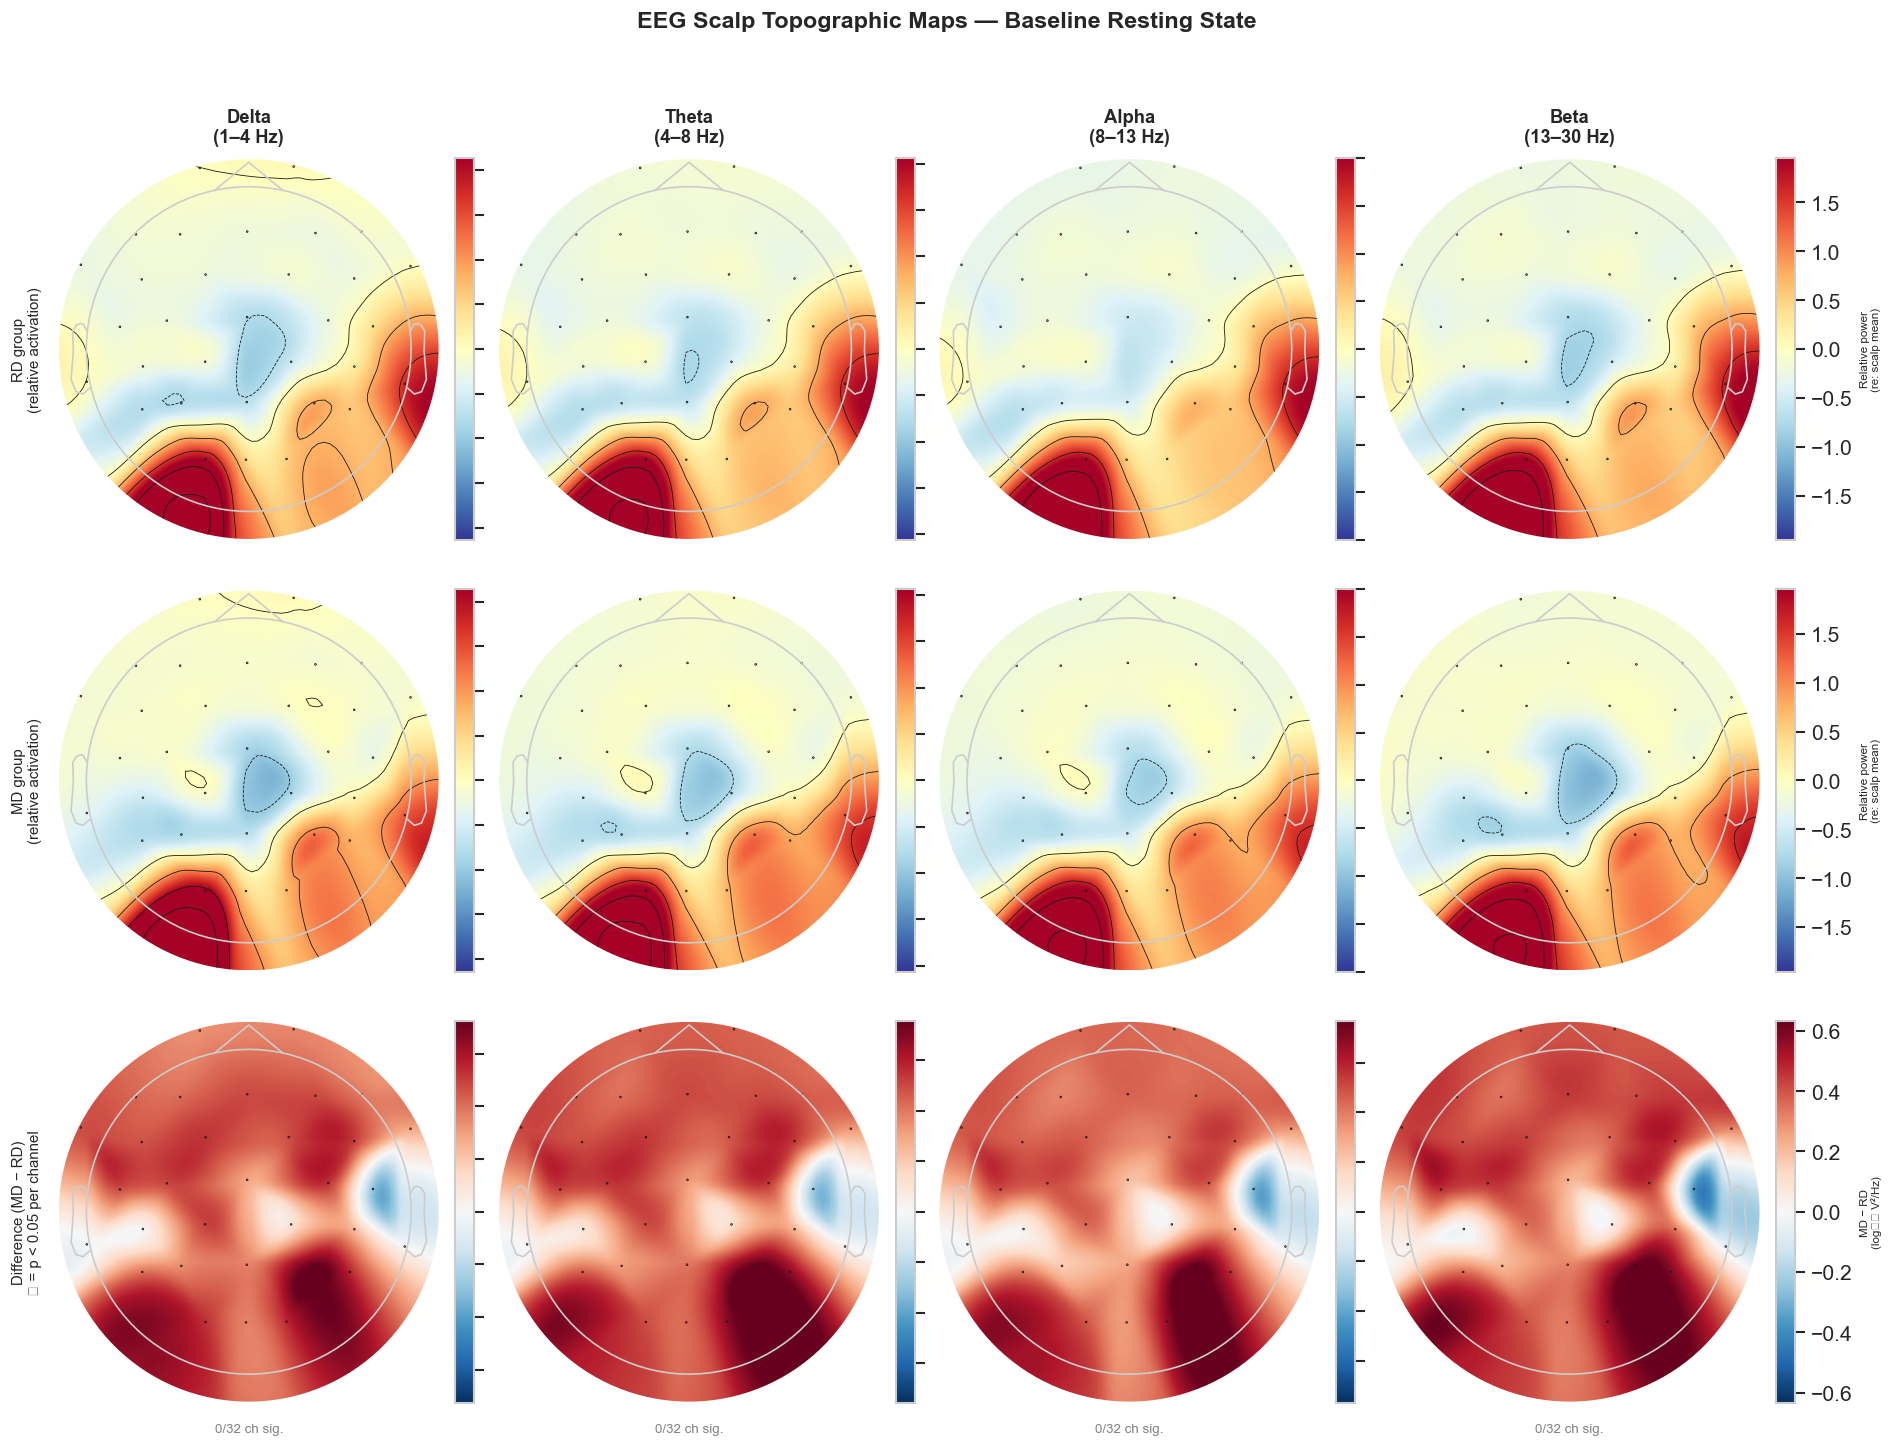

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle('EEG Scalp Topographic Maps \n Baseline Resting State',
             fontsize=14, fontweight='bold', y=1.01)

band_labels = [f'{b.capitalize()}\n({lo}–{hi} Hz)' for b,(lo,hi) in BANDS.items()]
row_labels  = ['RD group\n(relative activation)', 
               'MD group\n(relative activation)', 
               'Difference (MD − RD)\n★ = p < 0.05 per channel']

for col_i, (band, blabel) in enumerate(zip(BANDS.keys(), band_labels)):

    rd_v   = mean_rd[band]     # (32,) group mean log10 power
    md_v   = mean_md[band]     # (32,)

    # ── Rows 0 & 1: mean-center each map so warm = above scalp average ────────
    # Subtracting the scalp mean makes the colormap show RELATIVE activation
    # (which regions are more active than average), not absolute power levels.
    rd_centered = rd_v - rd_v.mean()
    md_centered = md_v - md_v.mean()
    vabs_grp    = max(np.abs(rd_centered).max(), np.abs(md_centered).max())

    for row_i, vals_c in enumerate([rd_centered, md_centered]):
        ax = axes[row_i, col_i]
        im, _ = mne.viz.plot_topomap(
            vals_c, info, axes=ax, show=False,
            cmap='RdYlBu_r',
            vlim=(-vabs_grp, vabs_grp),
            contours=5,
            sphere=0.09,
            extrapolate='head'
        )
        cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        if col_i == 3:
            cb.set_label('Relative power\n(re: scalp mean)', fontsize=7)
        else:
            cb.set_ticklabels([])

        if row_i == 0:
            ax.set_title(blabel, fontsize=11, fontweight='bold', pad=10)
        if col_i == 0:
            ax.set_ylabel(row_labels[row_i], fontsize=9, labelpad=10)

    # ── Row 2: difference map with per-channel statistical mask ───────────────
    # For each of the 32 channels, run a Mann-Whitney U test (RD vs MD).
    # The mask highlights only channels where the difference is significant
    # (p < 0.05): large filled markers = significant, small dots = n.s.
    diff_v = md_v - rd_v
    vabs_d = np.abs(diff_v).max()

    n_ch   = perch_rd[band].shape[1]
    p_vals = np.array([
        stats.mannwhitneyu(
            perch_rd[band][:, ch],
            perch_md[band][:, ch],
            alternative='two-sided'
        )[1]
        for ch in range(n_ch)
    ])
    sig_mask = p_vals < 0.05

    ax = axes[2, col_i]
    im, _ = mne.viz.plot_topomap(
        diff_v, info, axes=ax, show=False,
        cmap='RdBu_r',
        vlim=(-vabs_d, vabs_d),
        contours=0,
        mask=sig_mask,
        mask_params=dict(
            marker='*',
            markerfacecolor='black',
            markeredgecolor='black',
            linewidth=0,
            markersize=7
        ),
        sphere=0.09,
        extrapolate='head'
    )
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    if col_i == 3:
        cb.set_label('MD − RD\n(log₁₀ V²/Hz)', fontsize=7)
    else:
        cb.set_ticklabels([])

    if col_i == 0:
        ax.set_ylabel(row_labels[2], fontsize=9, labelpad=10)

    # Annotate number of significant channels
    n_sig = sig_mask.sum()
    ax.text(0.5, -0.08, f'{n_sig}/32 ch sig.',
            transform=ax.transAxes, ha='center', fontsize=8,
            color='darkred' if n_sig > 0 else 'gray',
            fontweight='bold' if n_sig > 0 else 'normal')

plt.tight_layout()
plt.savefig(FIG_DIR / '04_topomaps_group.png', bbox_inches='tight', dpi=150)
plt.show()

**Interpretation:** 

Both groups share a dominan right posterior/temporal activation pattern across all frequency bands during resting state. Warm regions (above scalp mean) concentrate consistenly in right occipital, temporal and parietal areas, while frontal and left hemisphere regions sit at or below the scalp average. Based on literature, this right-posterior dominance, that is consistent across delta, theta, alpha and beta, reflects a structural feature of the neural architecture in children with learning difficulties.

Comparing the two groups, the RD group shows a more focal and concentrated right temporal hot spot, particularly visible in theta and alpha, which may reflect regions associated with visual word form processing. The MD group shows a  similar pattern but with slightly more distributed frontal-central activation, consistent with greater working memory network engagement at rest.


The difference maps (MD − RD) confirm a global tendency for MD > RD power across most of the scalp (warm bias), with localized RD > MD in right occipital channels (blue patches). 

### 3.3 Topographic Shift: Baseline vs Task

Within each group, we compare how does the scalp distribution change from resting state (our baseline) to active cognitive task (reading for RD, arithmetic for MD). We focus on theta and alpa, the bands most sensitive to cognitive engagement.

If EEG captures genuine cognitive activity, topomaps should shift during task engagment. We expect somehting like:

- **Alpha decrease** during task (alpha suppression = active visual/cognitive processing)
- **Theta increase** frontally during working memory load

This validates that our EEG features reflect real neurocognitive states, and would be useful for our future models.

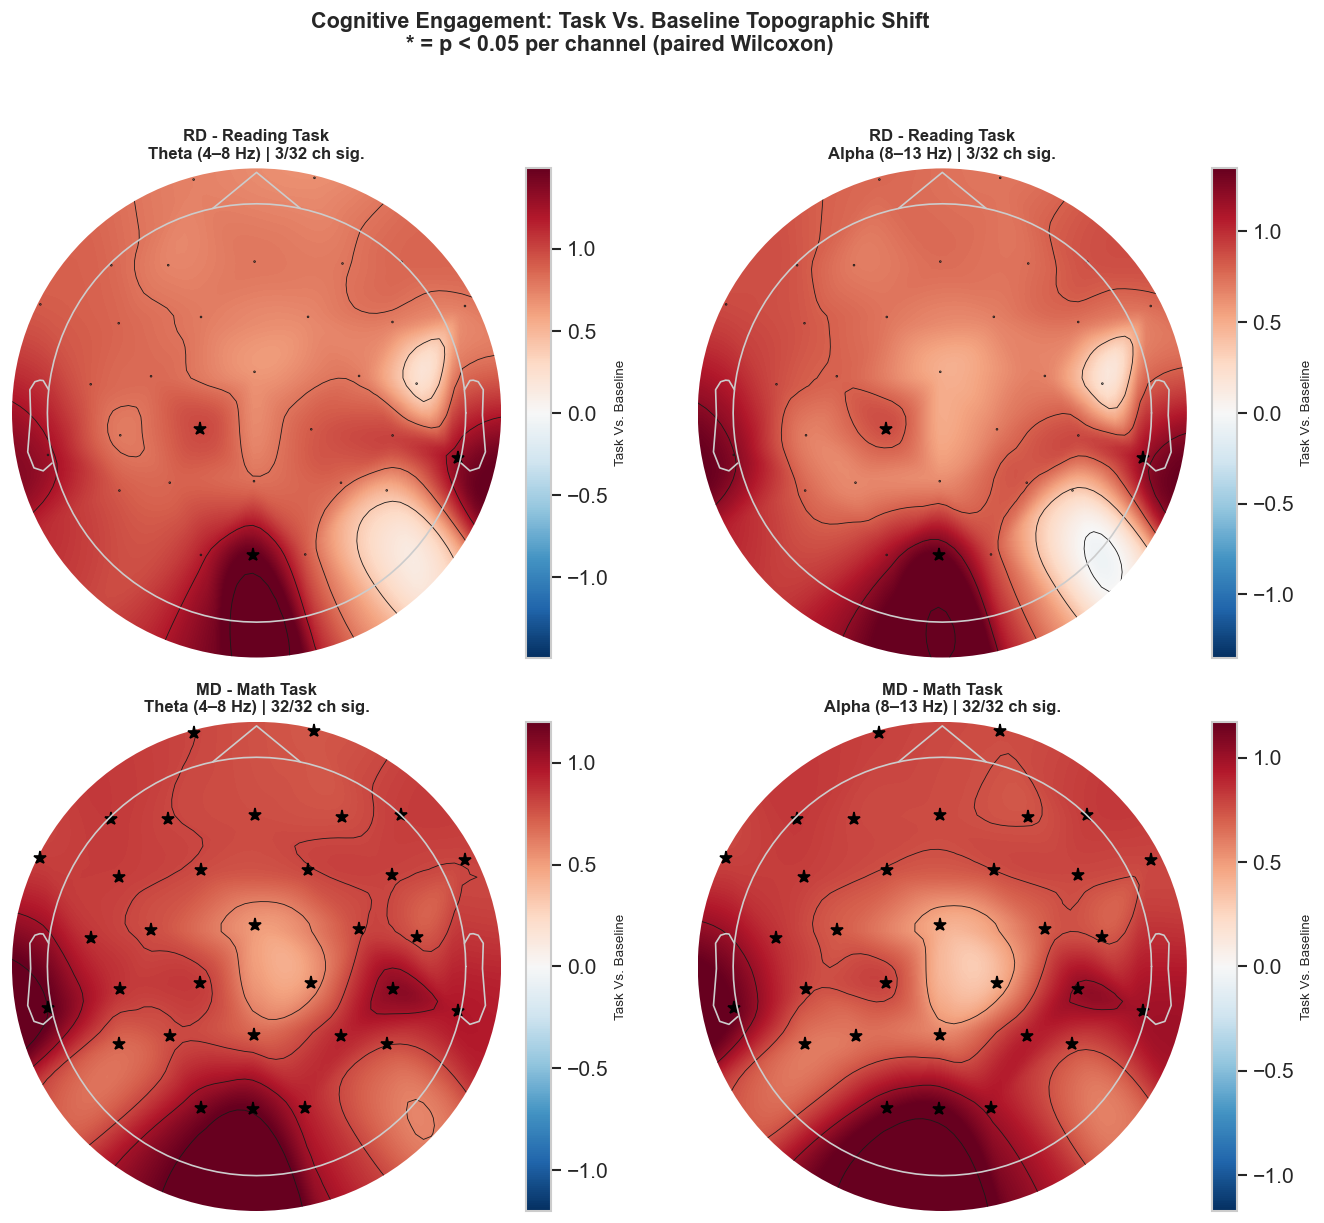

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Cognitive Engagement: Task Vs. Baseline Topographic Shift\n'
             '* = p < 0.05 per channel (paired Wilcoxon)',
             fontsize=13, fontweight='bold', y=1.02)

groups_cfg = [
    ('RD', 'Reading Task', perch_rd, task_rd,  'theta', axes[0,0]),
    ('RD', 'Reading Task', perch_rd, task_rd,  'alpha', axes[0,1]),
    ('MD', 'Math Task',    perch_md, task_md,  'theta', axes[1,0]),
    ('MD', 'Math Task',    perch_md, task_md,  'alpha', axes[1,1]),
]

for group, task_label, base_dict, task_dict, band, ax in groups_cfg:

    # Align subjects present in BOTH baseline and task
    n_base = base_dict[band].shape[0]
    n_task = task_dict[band].shape[0]
    n_min  = min(n_base, n_task)
    base_m = base_dict[band][:n_min]
    task_m = task_dict[band][:n_min]

    # Task - Baseline difference (group mean)
    diff_v = task_m.mean(axis=0) - base_m.mean(axis=0)
    vabs   = np.abs(diff_v).max()

    # Per-channel paired Wilcoxon test (Task vs Baseline, within-subject)
    n_ch   = diff_v.shape[0]
    p_vals = np.array([
        stats.wilcoxon(task_m[:, ch], base_m[:, ch])[1]
        for ch in range(n_ch)
    ])
    sig_mask = p_vals < 0.05

    im, _ = mne.viz.plot_topomap(
        diff_v, info, axes=ax, show=False,
        cmap='RdBu_r',
        vlim=(-vabs, vabs),
        contours=4,
        mask=sig_mask,
        mask_params=dict(marker='*', markerfacecolor='black',
                         markeredgecolor='black', linewidth=0, markersize=8),
        sphere=0.09,
        extrapolate='head'
    )
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label('Task Vs. Baseline', fontsize=8)

    lo, hi = BANDS[band]
    n_sig  = sig_mask.sum()
    ax.set_title(f'{group} - {task_label}\n'
                 f'{band.capitalize()} ({lo}–{hi} Hz) | {n_sig}/32 ch sig.',
                 fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(FIG_DIR / '05_topomap_baseline_task.png', bbox_inches='tight', dpi=150)
plt.show()

**Interpretation:**

The contrast between the two groups is one of the most informative findings of this analysis.

RD group during Reading Task (3/32 channels significant): The reading task produces only a 3 channels that spatially sparse neural shift from baseline. Theta and alpha power increase slightly across most of the scalp, but only 3 channels reach significance in each band. Notably, a small right posterior region shows a decrease in both theta and alpha during reading, it was the same region that was most active at rest. This partial suppression of the right posterior resting network during the reading task may reflect an attempt to shift processing toward left-hemisphere language networks, but the effect is weak and non-significant across most of the scalp. 

MD group during Math Task (32/32 channels significant in both theta and alpha): The math task produces a massive, statistically significant global power increase across all 32 channels in both bands. The global theta synchronization reflects intense cognitive load, MD children require disproportionate working memory. 

The key asymmetry: RD children's brains respond minimally to their respective cognitive challenge, MD children's brains respond maximally to theirs. This reflects a fundamental difference in how each group recruits neural resources during their domain cognitive demands.

This EEG features carry strong discriminative information beyond the resting state baseline alone. The huge difference between groups directly motivates including both the baseline and task features in the classification pipeline. This also suggests the attention-gating model should learn to weight task features more heavily for the RD/MD classification.

## 4 · Regional EEG Band Power - Group Comparison

### 4.1 Band Power Heatmaps

We created heatmaps of bandpower per brain region x frequency band for RD, MD and their difference during baseline.

While our topomaps show spation distribution at channel level, regional heatmaps aggregate into the 7 anatomical regions used in our ML pipeline.

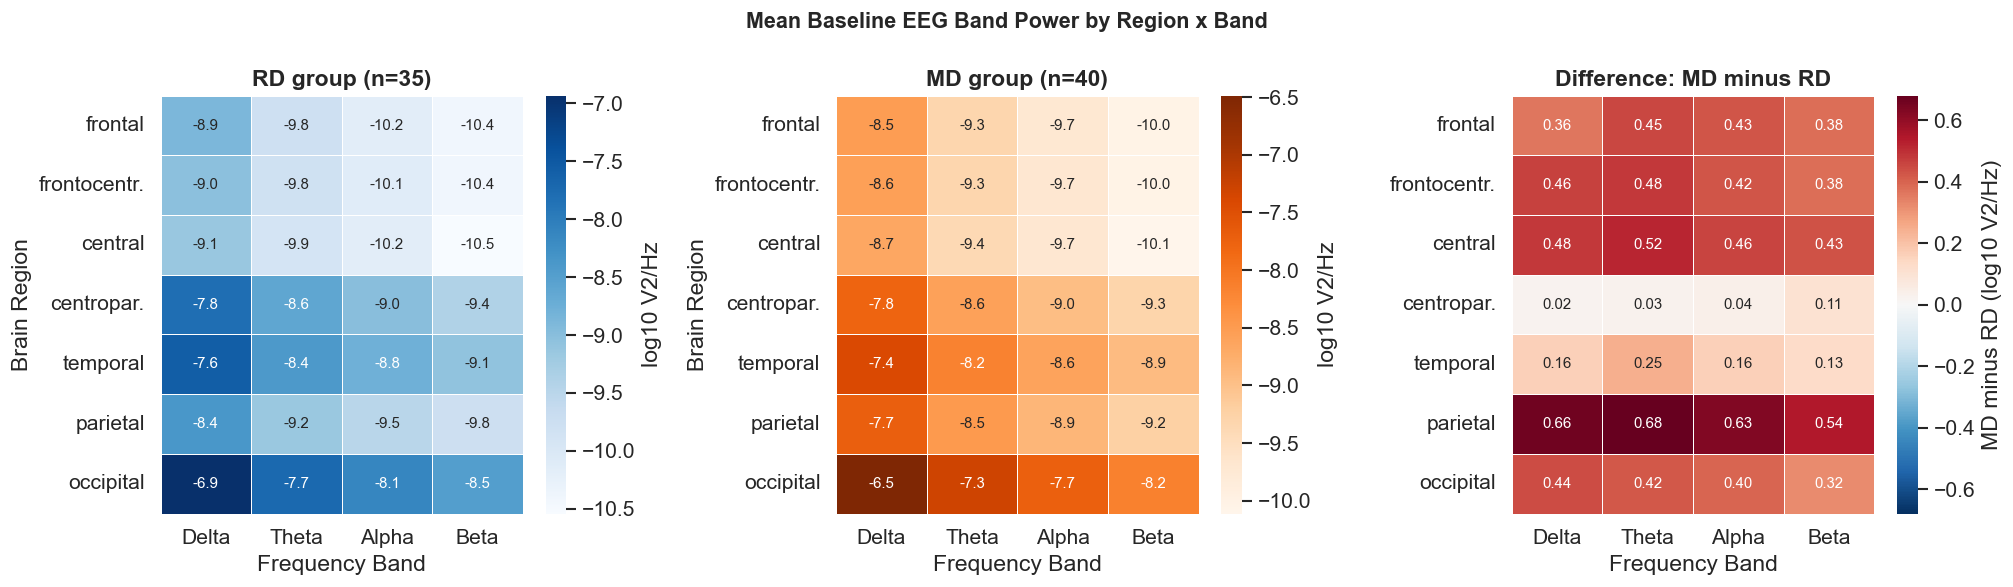

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

fig.suptitle('Mean Baseline EEG Band Power by Region x Band',fontsize=13, fontweight='bold')

band_names    = [b.capitalize() for b in BANDS]
region_labels = [r.replace('centroparietal','centropar.').replace('frontocentral','frontocentr.')
                 for r in REGIONS]

heat_rd = np.zeros((len(REGIONS), len(BANDS)))
heat_md = np.zeros((len(REGIONS), len(BANDS)))

for ax_idx, (group, color_map, heat_arr) in enumerate([
    ('RD', 'Blues', heat_rd), ('MD', 'Oranges', heat_md)]):
    ax   = axes[ax_idx]
    grp  = eeg[eeg.label==group]
    for i, reg in enumerate(REGIONS):
        for j, band in enumerate(BANDS):
            col = f'baseline_{reg}_{band}'
            heat_arr[i,j] = grp[col].mean() if col in grp.columns else np.nan
    sns.heatmap(heat_arr, ax=ax, annot=True, fmt='.1f', cmap=color_map,
                xticklabels=band_names, yticklabels=region_labels,
                linewidths=0.5, cbar_kws={'label': 'log10 V2/Hz'},
                annot_kws={'size': 9})
    n = (eeg.label==group).sum()
    ax.set_title(f'{group} group (n={n})', fontweight='bold')
    ax.set_xlabel('Frequency Band'); ax.set_ylabel('Brain Region')

diff = heat_md - heat_rd
vabs = np.abs(diff).max()
sns.heatmap(diff, ax=axes[2], annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-vabs, vmax=vabs,
            xticklabels=band_names, yticklabels=region_labels,
            linewidths=0.5, cbar_kws={'label': 'MD minus RD (log10 V2/Hz)'},
            annot_kws={'size': 9})
axes[2].set_title('Difference: MD minus RD', fontweight='bold')
axes[2].set_xlabel('Frequency Band'); axes[2].set_ylabel('')

plt.tight_layout()
plt.savefig(FIG_DIR/'06_regional_heatmaps.png', bbox_inches='tight', dpi=150)
plt.show()

**Interpretation:** 

The parietal region shows the largest MD−RD difference across all four bands, making it the single most discriminative region in the feature space. Parietal cortex is a core hub for visuospatial processing, numerical magnitude representation, and arithmetic fact retrieval. Its elevated resting-state power in MD children suggests altered baseline excitability in the circuits most implicated in mathematical cognition.
On the other hand, the centroparietal region shows almost no difference between groups. This is anatomically specific, a region less directly implicated in the reading-vs-math distinction than posterior parietal or frontal sites.

For our ML pipeline, this heatmap provides a data driven prediction: parietal features should receive the highest feature importance in the classifier, followed by frontal/frontocentral features. Centroparietal features will likely contribute the least. We will test this prediction in future notebooks.

## 5 · Cross-Modal Correlations

### 5.1 EEG vs Psychometrics. The question is: Do Both Modalities Tell the Same Story?

We will use spearman correalation between EEG baseline features and shared psychometric variables (IQ and selective attention) across all 75 subjects.

This directly answers the central question motivating our multimodal fusion. If correlations are weak the modalities capture different aspectos of the child's neurocogntive profile, and combining them via a lerned attention gate should improve classification. If correlation are strong, psychometrics should be suffice. This is our empirical justification for our architecture.

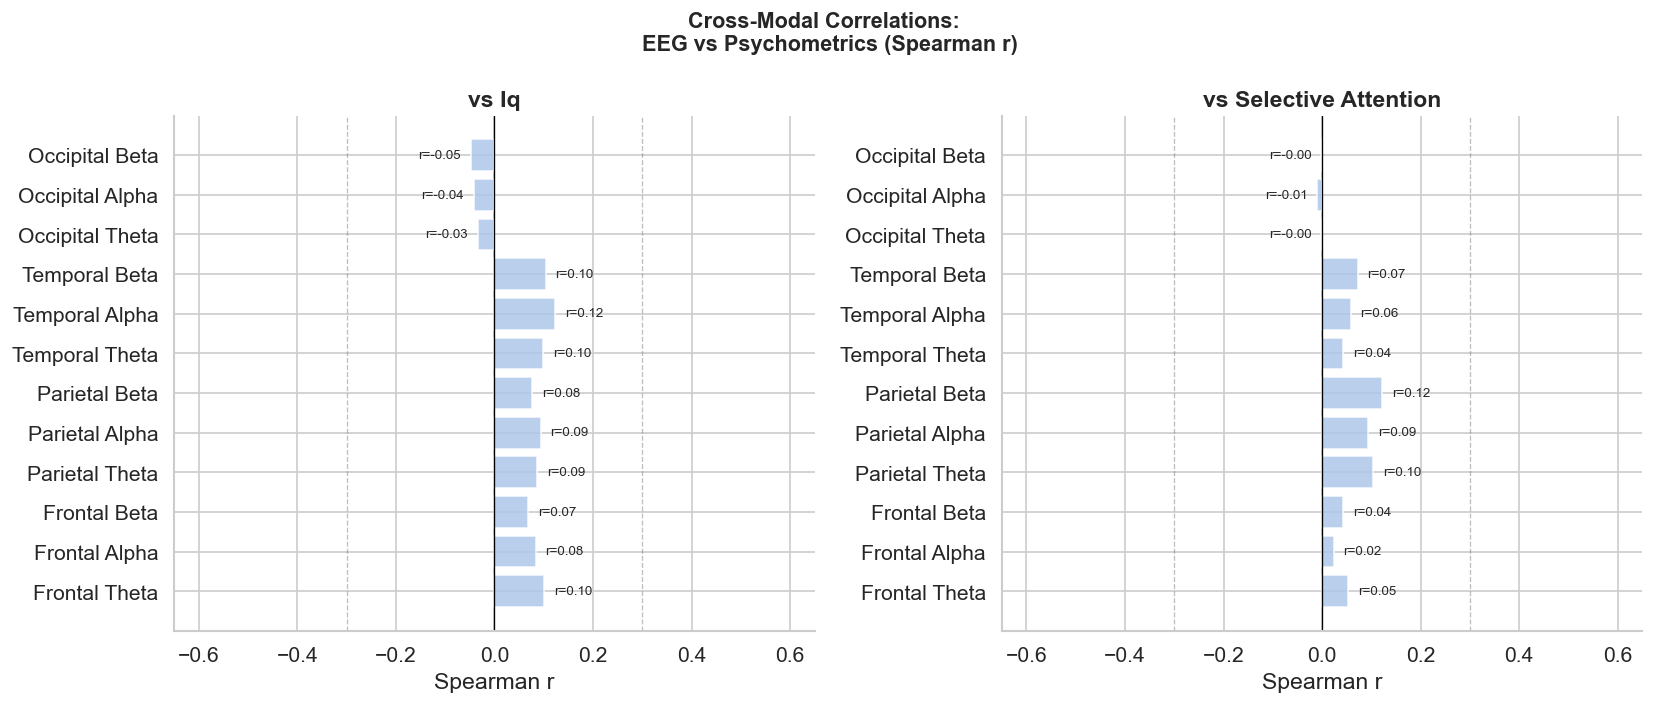

In [43]:
merged = pd.merge(eeg, psycho, on=['subject_id','label'])

eeg_select    = [f'baseline_{r}_{b}'
                 for r in ['frontal','parietal','temporal','occipital']
                 for b in ['theta','alpha','beta']]
psycho_select = ['IQ','selective_attention']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Cross-Modal Correlations: \n EEG vs Psychometrics (Spearman r)',
             fontsize=13, fontweight='bold')

for ax, pcol in zip(axes, psycho_select):
    corrs, pvals, ylabels = [], [], []
    for ecol in eeg_select:
        sub = merged[[ecol, pcol]].dropna()
        if len(sub) < 10: continue
        r, p = stats.spearmanr(sub[ecol], sub[pcol])
        corrs.append(r); pvals.append(p)
        ylabels.append(ecol.replace('baseline_','').replace('_',' ').title())
    colors = ['#d62728' if abs(r)>0.3 else '#aec7e8' for r in corrs]
    bars   = ax.barh(ylabels, corrs, color=colors, alpha=0.85, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.axvline( 0.3, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.axvline(-0.3, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_xlim(-0.65, 0.65)
    ax.set_xlabel('Spearman r')
    ax.set_title(f'vs {pcol.replace("_"," ").title()}', fontweight='bold')
    for bar, r, p in zip(bars, corrs, pvals):
        sig  = '*' if p<0.05 else ''
        xoff = 0.02 if r>=0 else -0.02
        ha   = 'left' if r>=0 else 'right'
        ax.text(r+xoff, bar.get_y()+bar.get_height()/2,
                f'r={r:.2f}{sig}', va='center', ha=ha, fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR/'08_crossmodal_correlations.png', bbox_inches='tight', dpi=150)
plt.show()

**Interpretation:**

The result is clear, all EEG-psychometric correlations are small across both panels (|r| < 0.15). No feature reaches statistical significance. The directions are mostly positive, but the relationships are far too weak to carry any practical meaning.

This is the most important analytic result for motivating the multimodal architecture. It establishes that EEG and psychometric scores measure fundamentally different aspects of the child's neurocognitive profile. Combining them in a fusion model is not redundant, because a model trained only on psychometrics captures behavioural variance and a model trained only on EEG captures neural variance. Therefore, an attention-gating model that fuses both can capture variance that neither modality explains alone.

## 7. Summary and Key Takeaways

**Conclusion:**

Based on the analyses above, the two modalities (EEG and psychometrics) carry **complementary** 
information about the children's learning difficulty profiles. This **justifies** the multimodal 
attention-gating approach developed in our future notebooks.

The psychometric modality provides behavioural evidence of each group's difficulty 
(reading errors, speed, math accuracy), but shared cognitive variables (IQ, attention) offer no 
discriminative signal. The EEG modality captures neural differences, particularly elevated 
parietal power in MD children and right posterior activation in RD, that are independent of 
psychometric scores. 

The EEG features most likely to be informative for classification are:

- **Parietal band power** (all four bands, baseline). Largest MD−RD difference
- **Task-condition features** (theta and alpha, all regions). Strongest neural engagement asymmetry
- **Frontal and frontocentral band power** (theta and beta, baseline). It's moderate but consistent group differences.
- **Occipital and temporal features**.